# Thyroid Disease Prediction Using ANN

Complete Colab notebook for deep-learning part.


- `data/processed/train.csv`
- `data/processed/test.csv`
- `data/processed/class_labels.json`

It includes baseline ANN training, class-weight handling, hyperparameter tuning, final evaluation, plots, predictions, and model export.


In [23]:
# CELL 1 — CLONE REPOSITORY
# =========================
import os
import subprocess

REPOSITORY_URL = "https://github.com/adhikari-arpan/Thyroid_Disease_Prediction.git"
REPOSITORY_PATH = "/content/Thyroid_Disease_Prediction"

if not os.path.exists(REPOSITORY_PATH):
    subprocess.run(
        ["git", "clone", REPOSITORY_URL, REPOSITORY_PATH],
        check=True
    )
else:
    print("Repository already exists:", REPOSITORY_PATH)

os.chdir(REPOSITORY_PATH)
print("Current folder:", os.getcwd())


# ===============================

Repository already exists: /content/Thyroid_Disease_Prediction
Current folder: /content/Thyroid_Disease_Prediction


In [24]:
# CELL 2 — INSTALL KERAS TUNER

!pip install -q keras-tuner


In [25]:
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import keras_tuner as kt

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


# ======================================

TensorFlow version: 2.20.0


In [26]:
# CELL 4 — PATHS AND OUTPUT DIRECTORIES
# ======================================
DATA_DIR = "data/processed"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
LABELS_PATH = os.path.join(DATA_DIR, "class_labels.json")

MODEL_DIR = "models"
RESULT_DIR = "results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

for required_path in [TRAIN_PATH, TEST_PATH, LABELS_PATH]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(
            f"Required file not found: {required_path}"
        )


# ==========================

In [27]:
# CELL 5 — LOAD SHARED DATA
# ==========================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(LABELS_PATH, "r", encoding="utf-8") as file:
    raw_class_labels = json.load(file)

# JSON keys are strings; convert them to integers.
CLASS_LABELS = {
    int(class_number): str(class_name)
    for class_number, class_name in raw_class_labels.items()
}

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("Class mapping:", CLASS_LABELS)
print(train_df.head())


# ===========================================

Training shape: (5760, 22)
Testing shape: (1440, 22)
Class mapping: {1: 'hyperthyroid', 2: 'hypothyroid', 3: 'normal'}
    age  sex  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  \
0  0.76    1             0                   0                          0   
1  0.61    0             1                   0                          0   
2  0.77    0             0                   0                          0   
3  0.69    0             0                   0                          0   
4  0.39    0             0                   1                          0   

   sick  pregnant  thyroid_surgery  I131_treatment  query_hypothyroid  ...  \
0     0         0                0               0                  0  ...   
1     0         0                0               0                  0  ...   
2     0         0                0               0                  0  ...   
3     0         0                0               0                  0  ...   
4     0         0           

In [28]:
# CELL 6 — VERIFY DATA WITHOUT CHANGING DATA
# ===========================================
TARGET_COLUMN = "class"

if TARGET_COLUMN not in train_df.columns:
    raise ValueError("'class' column is missing from train.csv.")

if TARGET_COLUMN not in test_df.columns:
    raise ValueError("'class' column is missing from test.csv.")

if train_df.columns.tolist() != test_df.columns.tolist():
    raise ValueError(
        "train.csv and test.csv do not contain the same columns."
    )

if train_df.isna().sum().sum() != 0:
    raise ValueError("Missing values exist in train.csv.")

if test_df.isna().sum().sum() != 0:
    raise ValueError("Missing values exist in test.csv.")

print("Number of input features:", train_df.shape[1] - 1)

print("\nTraining class counts:")
print(train_df[TARGET_COLUMN].value_counts().sort_index())

print("\nTesting class counts:")
print(test_df[TARGET_COLUMN].value_counts().sort_index())


# ==================================

Number of input features: 21

Training class counts:
class
1     133
2     294
3    5333
Name: count, dtype: int64

Testing class counts:
class
1      33
2      74
3    1333
Name: count, dtype: int64


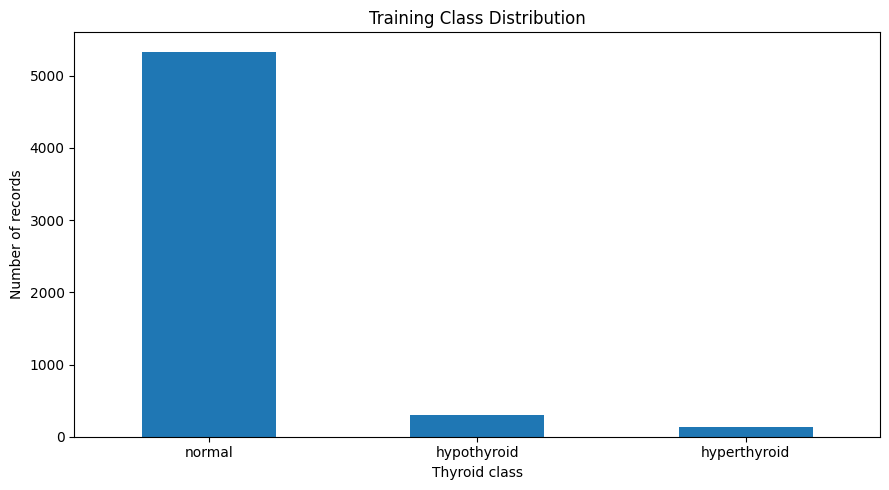

In [29]:
# CELL 7 — PLOT CLASS DISTRIBUTION
# ==================================
train_class_names = train_df[TARGET_COLUMN].map(CLASS_LABELS)

plt.figure(figsize=(9, 5))
train_class_names.value_counts().plot(kind="bar")
plt.title("Training Class Distribution")
plt.xlabel("Thyroid class")
plt.ylabel("Number of records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, "training_class_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# =======================================

In [30]:
# CELL 8 — SEPARATE FEATURES AND TARGETS
# =======================================
X_train_full = train_df.drop(
    columns=[TARGET_COLUMN]
).astype("float32")

X_test = test_df.drop(
    columns=[TARGET_COLUMN]
).astype("float32")

y_train_original = train_df[TARGET_COLUMN].astype("int32")
y_test_original = test_df[TARGET_COLUMN].astype("int32")

print("X_train_full:", X_train_full.shape)
print("X_test:", X_test.shape)
print("Original target labels:", sorted(y_train_original.unique()))


# =====================================================

X_train_full: (5760, 21)
X_test: (1440, 21)
Original target labels: [np.int32(1), np.int32(2), np.int32(3)]


In [31]:
# CELL 9 — CHANGE TARGETS FROM 1,2,3 TO 0,1,2 FOR ANN
# =====================================================
# Shared CSV files remain unchanged.
# This conversion is only used internally by TensorFlow.

minimum_label = int(
    min(y_train_original.min(), y_test_original.min())
)

if minimum_label != 1:
    raise ValueError(
        "Expected original class labels to start at 1."
    )

y_train_full = (y_train_original - 1).astype("int32")
y_test = (y_test_original - 1).astype("int32")

ANN_CLASS_LABELS = {
    original_label - 1: class_name
    for original_label, class_name in CLASS_LABELS.items()
}

NUM_CLASSES = len(ANN_CLASS_LABELS)
NUM_FEATURES = X_train_full.shape[1]

print("ANN class mapping:", ANN_CLASS_LABELS)
print("Number of classes:", NUM_CLASSES)
print("Number of features:", NUM_FEATURES)


# ==========================================

ANN class mapping: {0: 'hyperthyroid', 1: 'hypothyroid', 2: 'normal'}
Number of classes: 3
Number of features: 21


In [32]:
# CELL 10 — CREATE ANN VALIDATION SUBSET
# ==========================================
# test.csv remains untouched until final evaluation.

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("ANN training shape:", X_train.shape)
print("ANN validation shape:", X_val.shape)
print("Final test shape:", X_test.shape)


# ==========================================

ANN training shape: (4608, 21)
ANN validation shape: (1152, 21)
Final test shape: (1440, 21)


In [33]:
# CELL 11 — CALCULATE BALANCED CLASS WEIGHTS
# ==========================================
class_numbers = np.unique(y_train)

calculated_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_numbers,
    y=y_train
)

class_weights = {
    int(class_number): float(weight)
    for class_number, weight in zip(
        class_numbers,
        calculated_weights
    )
}

print("Class weights:")
for class_number, weight in class_weights.items():
    print(
        f"{class_number} "
        f"({ANN_CLASS_LABELS[class_number]}): "
        f"{weight:.4f}"
    )


# ==================================

Class weights:
0 (hyperthyroid): 14.3551
1 (hypothyroid): 6.5362
2 (normal): 0.3601


In [34]:
# CELL 12 — BUILD BASELINE ANN MODEL
# ==================================
def build_baseline_model() -> keras.Model:
    model = keras.Sequential([
        keras.Input(
            shape=(NUM_FEATURES,),
            name="thyroid_features"
        ),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0001)
        ),

        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0001)
        ),

        layers.Dropout(0.20),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            name="thyroid_class"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model


baseline_model = build_baseline_model()
baseline_model.summary()


# ===================================

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ thyroid_class (Dense)           │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843 (15.01 KB)

 Trainable params: 3,715 (14.51 KB)

 Non-trainable params: 128 (512.00 B)

In [35]:
# CELL 13 — BASELINE MODEL CALLBACKS
# ===================================
baseline_model_path = os.path.join(
    MODEL_DIR,
    "baseline_thyroid_ann.keras"
)

baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=baseline_model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]


# ================================

In [36]:
# CELL 14 — TRAIN BASELINE MODEL
# ================================
baseline_history = baseline_model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=150,
    batch_size=32,

    class_weight=class_weights,
    callbacks=baseline_callbacks,

    verbose=1
)


# =============================================

Epoch 1/150
138/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3000 - loss: 1.3441
Epoch 1: val_loss improved from None to 0.99187, saving model to models/baseline_thyroid_ann.keras

Epoch 1: finished saving model to models/baseline_thyroid_ann.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3305 - loss: 1.2132 - val_accuracy: 0.8767 - val_loss: 0.9919 - learning_rate: 0.0010
Epoch 2/150
138/144 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4317 - loss: 0.9945
Epoch 2: val_loss improved from 0.99187 to 0.90360, saving model to models/baseline_thyroid_ann.keras

Epoch 2: finished saving model to models/baseline_thyroid_ann.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4403 - loss: 0.9541 - val_accuracy: 0.7752 - val_loss: 0.9036 - learning_rate: 0.0010
Epoch 3/150
140/144 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4983 - loss: 0.8975
Epoch 3: val_loss improved from 0.90360 to 0.72886, saving model to models/baseline_thyroid_ann.keras

Epoch 3: fini

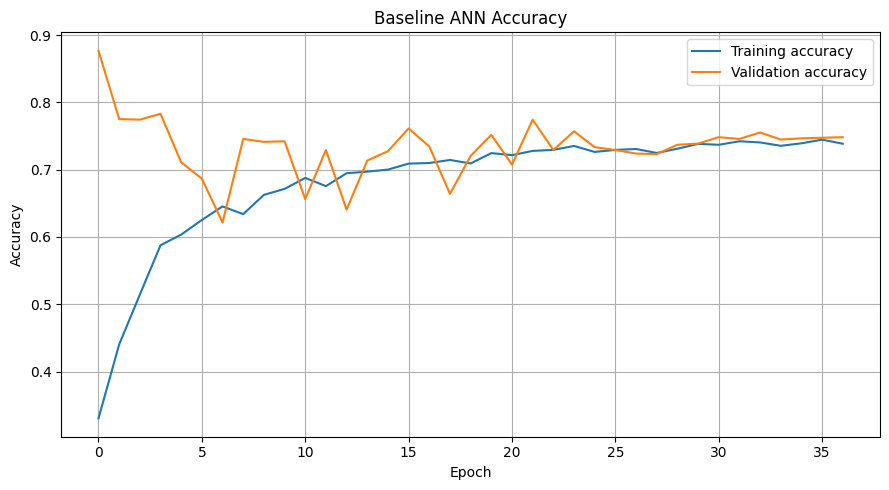

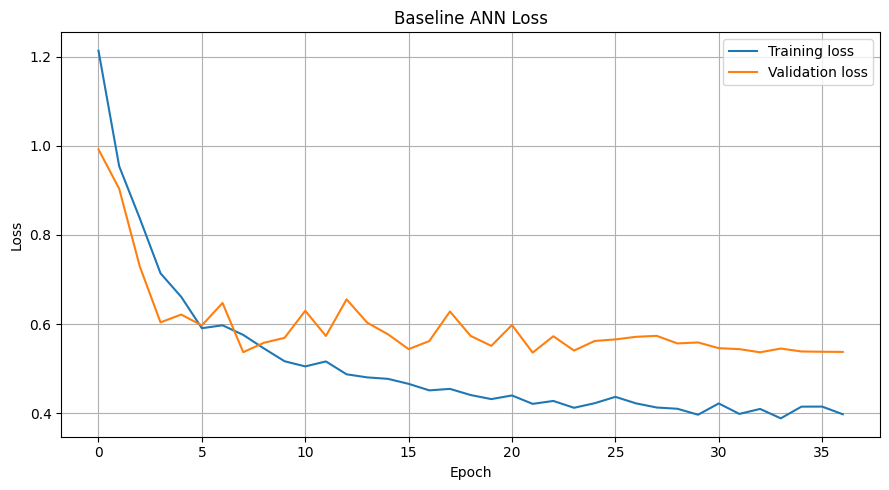

In [37]:
# CELL 15 — FUNCTION TO PLOT TRAINING HISTORY
# =============================================
def plot_training_history(
    history: keras.callbacks.History,
    model_title: str,
    output_prefix: str
) -> None:
    plt.figure(figsize=(9, 5))
    plt.plot(
        history.history["accuracy"],
        label="Training accuracy"
    )
    plt.plot(
        history.history["val_accuracy"],
        label="Validation accuracy"
    )
    plt.title(f"{model_title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{output_prefix}_accuracy.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(
        history.history["loss"],
        label="Training loss"
    )
    plt.plot(
        history.history["val_loss"],
        label="Validation loss"
    )
    plt.title(f"{model_title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{output_prefix}_loss.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


plot_training_history(
    baseline_history,
    model_title="Baseline ANN",
    output_prefix="baseline_ann"
)


# =============================================

In [38]:
# CELL 16 — REUSABLE MULTICLASS EVALUATION
# =============================================
def evaluate_model(
    model: keras.Model,
    X_data: pd.DataFrame,
    y_true: pd.Series,
    model_name: str,
    output_prefix: str
):
    probabilities = model.predict(
        X_data,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    metrics = {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),

        "Macro Precision": precision_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        )
    }

    target_names = [
        ANN_CLASS_LABELS[class_number]
        for class_number in range(NUM_CLASSES)
    ]

    report = classification_report(
        y_true,
        predictions,
        labels=np.arange(NUM_CLASSES),
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=False
    )

    print(f"\n{model_name} classification report:\n")
    print(report)

    with open(
        os.path.join(
            RESULT_DIR,
            f"{output_prefix}_classification_report.txt"
        ),
        "w",
        encoding="utf-8"
    ) as file:
        file.write(report)

    cm = confusion_matrix(
        y_true,
        predictions,
        labels=np.arange(NUM_CLASSES)
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    )

    matrix_display.plot(
        ax=ax,
        values_format="d",
        xticks_rotation=30
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            RESULT_DIR,
            f"{output_prefix}_confusion_matrix.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    prediction_results = pd.DataFrame({
        "Actual ANN Label": np.asarray(y_true),
        "Predicted ANN Label": predictions,
        "Actual Class": [
            ANN_CLASS_LABELS[int(label)]
            for label in np.asarray(y_true)
        ],
        "Predicted Class": [
            ANN_CLASS_LABELS[int(label)]
            for label in predictions
        ],
        "Confidence": np.max(
            probabilities,
            axis=1
        )
    })

    prediction_results.to_csv(
        os.path.join(
            RESULT_DIR,
            f"{output_prefix}_predictions.csv"
        ),
        index=False
    )

    return metrics, predictions, probabilities


# ===========================================


Baseline ANN classification report:

              precision    recall  f1-score   support

hyperthyroid     0.5273    0.8788    0.6591        33
 hypothyroid     0.1313    0.5946    0.2152        74
      normal     0.9724    0.7659    0.8569      1333

    accuracy                         0.7597      1440
   macro avg     0.5437    0.7464    0.5771      1440
weighted avg     0.9190    0.7597    0.8194      1440



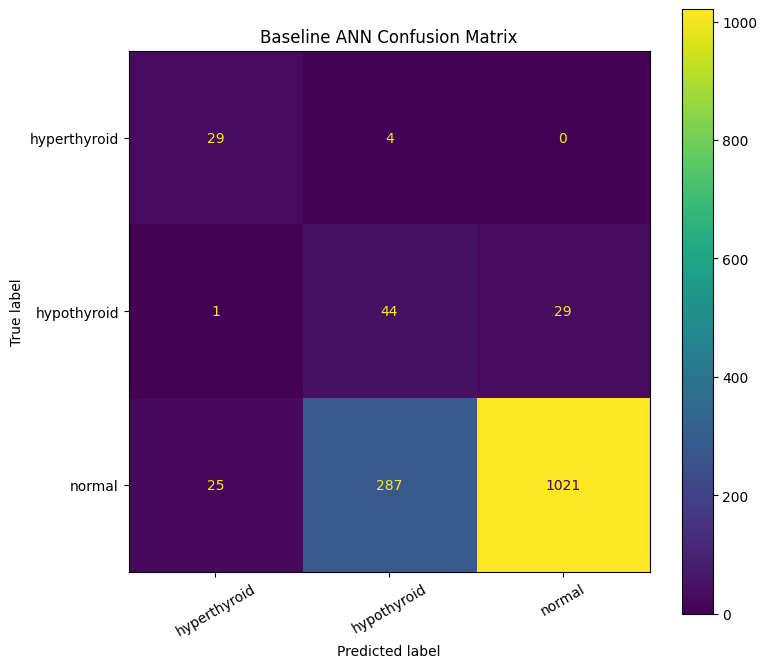

          Model  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  \
0  Baseline ANN  0.759722           0.746441         0.543666      0.746441   

   Macro F1  Weighted F1  
0  0.577051     0.819391  


In [39]:
# CELL 17 — EVALUATE BASELINE ON FINAL TEST
# ===========================================
baseline_model = keras.models.load_model(
    baseline_model_path
)

(
    baseline_metrics,
    baseline_predictions,
    baseline_probabilities
) = evaluate_model(
    model=baseline_model,
    X_data=X_test,
    y_true=y_test,
    model_name="Baseline ANN",
    output_prefix="baseline_ann"
)

print(pd.DataFrame([baseline_metrics]))


# =====================================

In [40]:
# CELL 18 — DEFINE TUNABLE ANN MODEL
# =====================================
def build_tunable_ann(
    hp: kt.HyperParameters
) -> keras.Model:
    model = keras.Sequential()

    model.add(
        keras.Input(shape=(NUM_FEATURES,))
    )

    first_units = hp.Choice(
        "first_units",
        values=[32, 64, 96, 128]
    )

    model.add(
        layers.Dense(
            first_units,
            activation="relu"
        )
    )

    if hp.Boolean("use_batch_normalization"):
        model.add(
            layers.BatchNormalization()
        )

    first_dropout = hp.Choice(
        "first_dropout",
        values=[0.10, 0.20, 0.30, 0.40]
    )

    model.add(
        layers.Dropout(first_dropout)
    )

    second_units = hp.Choice(
        "second_units",
        values=[16, 32, 48, 64]
    )

    model.add(
        layers.Dense(
            second_units,
            activation="relu"
        )
    )

    second_dropout = hp.Choice(
        "second_dropout",
        values=[0.10, 0.20, 0.30]
    )

    model.add(
        layers.Dropout(second_dropout)
    )

    model.add(
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.01, 0.001, 0.0005, 0.0001]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model


# =========================================

In [41]:
# CELL 19 — CONFIGURE HYPERPARAMETER TUNER
# =========================================
tuner = kt.RandomSearch(
    hypermodel=build_tunable_ann,

    objective=kt.Objective(
        "val_loss",
        direction="min"
    ),

    max_trials=12,
    executions_per_trial=1,

    overwrite=True,

    directory="ann_tuning",
    project_name="thyroid_ann",

    seed=SEED
)

tuner.search_space_summary()


# ==================================

Search space summary
Default search space size: 6
first_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 96, 128], 'ordered': True}
use_batch_normalization (Boolean)
{'default': False, 'conditions': []}
first_dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3, 0.4], 'ordered': True}
second_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 48, 64], 'ordered': True}
second_dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}


In [42]:
# CELL 20 — RUN ANN TUNING SEARCH
# ==================================
tuning_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
]

tuner.search(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=80,
    batch_size=32,

    class_weight=class_weights,
    callbacks=tuning_callbacks,

    verbose=1
)


# =======================================

Trial 12 Complete [00h 00m 15s]
val_loss: 0.4368690550327301

Best val_loss So Far: 0.11720042675733566
Total elapsed time: 00h 05m 12s


In [43]:
# CELL 21 — GET BEST HYPERPARAMETERS
# =======================================
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

best_hyperparameters = {
    "first_units": best_hp.get("first_units"),
    "use_batch_normalization": best_hp.get(
        "use_batch_normalization"
    ),
    "first_dropout": best_hp.get(
        "first_dropout"
    ),
    "second_units": best_hp.get(
        "second_units"
    ),
    "second_dropout": best_hp.get(
        "second_dropout"
    ),
    "learning_rate": best_hp.get(
        "learning_rate"
    )
}

print("Best ANN hyperparameters:")
for name, value in best_hyperparameters.items():
    print(f"{name}: {value}")

with open(
    os.path.join(
        RESULT_DIR,
        "best_ann_hyperparameters.json"
    ),
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        best_hyperparameters,
        file,
        indent=4
    )


# ===================================

Best ANN hyperparameters:
first_units: 128
use_batch_normalization: False
first_dropout: 0.2
second_units: 48
second_dropout: 0.1
learning_rate: 0.001


Epoch 1/150
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3138 - loss: 1.0934
Epoch 1: val_loss improved from None to 0.90755, saving model to models/tuned_thyroid_ann.keras

Epoch 1: finished saving model to models/tuned_thyroid_ann.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4755 - loss: 1.0658 - val_accuracy: 0.6667 - val_loss: 0.9075 - learning_rate: 0.0010
Epoch 2/150
135/144 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6394 - loss: 0.9584
Epoch 2: val_loss improved from 0.90755 to 0.71030, saving model to models/tuned_thyroid_ann.keras

Epoch 2: finished saving model to models/tuned_thyroid_ann.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6523 - loss: 0.9094 - val_accuracy: 0.6944 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 3/150
135/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6524 - loss: 0.7528
Epoch 3: val_loss improved from 0.71030 to 0.66573, saving model to models/tuned_thyroid_ann.keras

Epoch 3: finished saving model

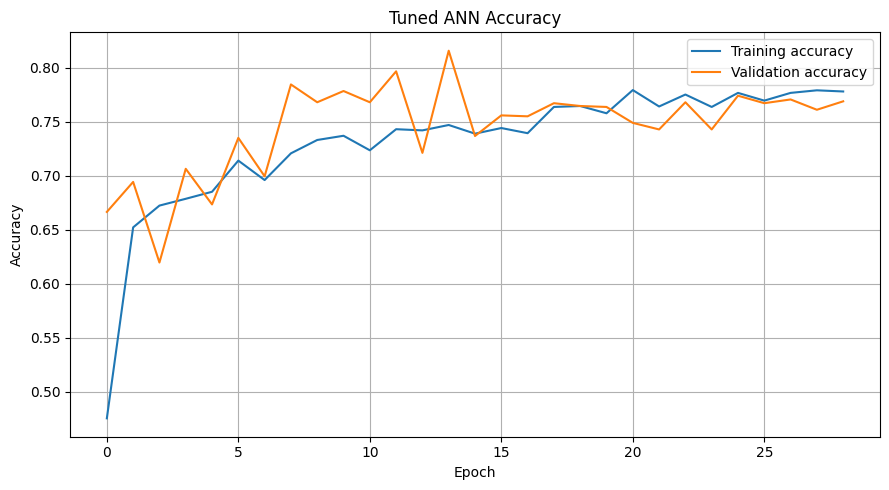

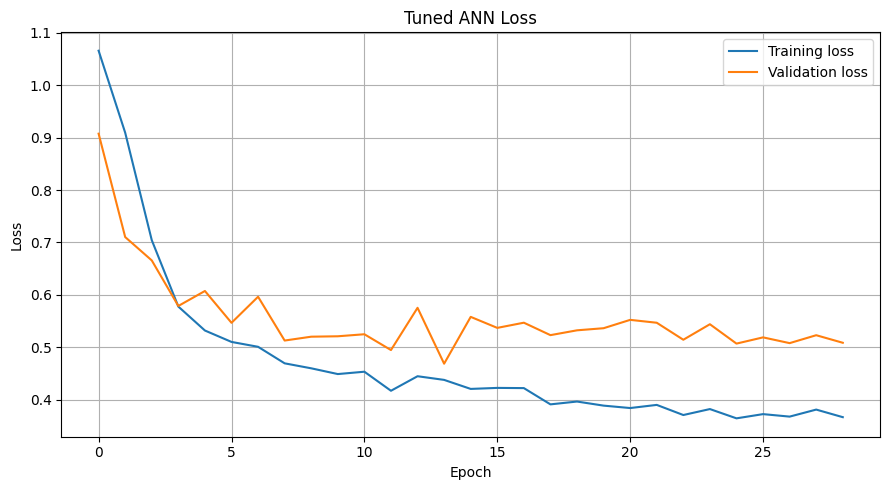

In [44]:
# CELL 22 — TRAIN FINAL TUNED MODEL
# ===================================
tuned_model = tuner.hypermodel.build(
    best_hp
)

tuned_model_path = os.path.join(
    MODEL_DIR,
    "tuned_thyroid_ann.keras"
)

tuned_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=tuned_model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

tuned_history = tuned_model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=150,
    batch_size=32,

    class_weight=class_weights,
    callbacks=tuned_callbacks,

    verbose=1
)

plot_training_history(
    tuned_history,
    model_title="Tuned ANN",
    output_prefix="tuned_ann"
)


# ========================================


Tuned ANN classification report:

              precision    recall  f1-score   support

hyperthyroid     0.7179    0.8485    0.7778        33
 hypothyroid     0.1397    0.5135    0.2197        74
      normal     0.9681    0.8200    0.8879      1333

    accuracy                         0.8049      1440
   macro avg     0.6086    0.7273    0.6284      1440
weighted avg     0.9198    0.8049    0.8510      1440



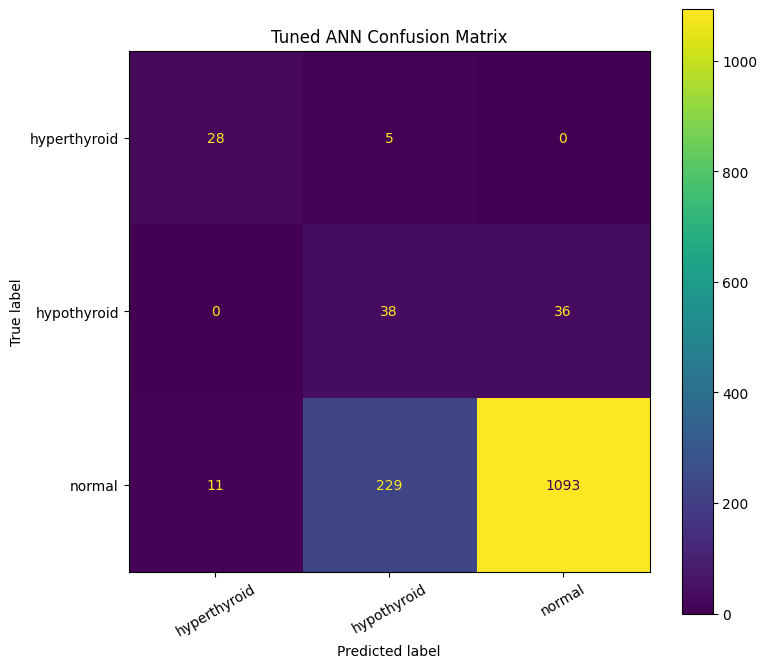

       Model  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  \
0  Tuned ANN  0.804861           0.727318         0.608589      0.727318   

   Macro F1  Weighted F1  
0  0.628442     0.851032  


In [45]:
# CELL 23 — EVALUATE FINAL TUNED MODEL
# ========================================
tuned_model = keras.models.load_model(
    tuned_model_path
)

(
    tuned_metrics,
    tuned_predictions,
    tuned_probabilities
) = evaluate_model(
    model=tuned_model,
    X_data=X_test,
    y_true=y_test,
    model_name="Tuned ANN",
    output_prefix="tuned_ann"
)

print(pd.DataFrame([tuned_metrics]))


# ==============================================

In [46]:
# CELL 24 — COMPARE BASELINE AND TUNED ANN
# ==============================================
ann_comparison = pd.DataFrame([
    baseline_metrics,
    tuned_metrics
])

print("\nBaseline versus tuned ANN:")
print(ann_comparison)

ann_comparison.to_csv(
    os.path.join(
        RESULT_DIR,
        "ann_before_after_tuning.csv"
    ),
    index=False
)


# =========================================


Baseline versus tuned ANN:
          Model  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  \
0  Baseline ANN  0.759722           0.746441         0.543666      0.746441   
1     Tuned ANN  0.804861           0.727318         0.608589      0.727318   

   Macro F1  Weighted F1  
0  0.577051     0.819391  
1  0.628442     0.851032  


In [47]:
# CELL 25 — PREDICT ONE TEST PATIENT
# =========================================
patient_index = 0

patient = X_test.iloc[
    [patient_index]
]

patient_probabilities = tuned_model.predict(
    patient,
    verbose=0
)[0]

predicted_ann_label = int(
    np.argmax(patient_probabilities)
)

actual_ann_label = int(
    y_test.iloc[patient_index]
)

print(
    "Actual class:",
    ANN_CLASS_LABELS[actual_ann_label]
)

print(
    "Predicted class:",
    ANN_CLASS_LABELS[predicted_ann_label]
)

print(
    f"Confidence: "
    f"{patient_probabilities[predicted_ann_label] * 100:.2f}%"
)

probability_table = pd.DataFrame({
    "Class": [
        ANN_CLASS_LABELS[class_number]
        for class_number in range(NUM_CLASSES)
    ],
    "Probability": patient_probabilities,
    "Percentage": patient_probabilities * 100
}).sort_values(
    by="Probability",
    ascending=False
)

print(probability_table)


# ====================================================

Actual class: normal
Predicted class: normal
Confidence: 81.35%
          Class  Probability  Percentage
2        normal     0.813454   81.345436
1   hypothyroid     0.186284   18.628428
0  hyperthyroid     0.000261    0.026138


In [48]:
# CELL 26 — FUNCTION FOR A PREPROCESSED NEW PATIENT
# ====================================================
def predict_preprocessed_patient(
    patient_features: dict
) -> pd.DataFrame:
    """
    Predict one patient whose 21 feature values are already in
    exactly the same numeric/normalized format as train.csv.

    Example:
        patient_features = {
            "age": 0.45,
            "sex": 0,
            ...
            "FTI": 0.12
        }

    This does not accept arbitrary raw laboratory units unless
    they already match the ANN-thyroid dataset's feature format.
    """
    expected_features = X_train_full.columns.tolist()

    missing_features = [
        feature
        for feature in expected_features
        if feature not in patient_features
    ]

    extra_features = [
        feature
        for feature in patient_features
        if feature not in expected_features
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    if extra_features:
        raise ValueError(
            f"Unexpected features: {extra_features}"
        )

    patient_df = pd.DataFrame(
        [patient_features]
    )[expected_features].astype("float32")

    probabilities = tuned_model.predict(
        patient_df,
        verbose=0
    )[0]

    predicted_label = int(
        np.argmax(probabilities)
    )

    result = pd.DataFrame({
        "Class": [
            ANN_CLASS_LABELS[class_number]
            for class_number in range(NUM_CLASSES)
        ],
        "Probability": probabilities,
        "Percentage": probabilities * 100
    }).sort_values(
        by="Probability",
        ascending=False
    )

    print(
        "Predicted class:",
        ANN_CLASS_LABELS[predicted_label]
    )

    print(
        f"Confidence: "
        f"{probabilities[predicted_label] * 100:.2f}%"
    )

    return result


# ==================================

In [49]:
# CELL 27 — SAVE MODEL INFORMATION
# ==================================
metadata = {
    "model_type": "Artificial Neural Network / MLP",
    "feature_names": X_train_full.columns.tolist(),
    "number_of_features": int(NUM_FEATURES),
    "number_of_classes": int(NUM_CLASSES),
    "original_class_labels": CLASS_LABELS,
    "ann_class_labels": ANN_CLASS_LABELS,
    "training_csv_rows": int(len(train_df)),
    "testing_csv_rows": int(len(test_df)),
    "validation_fraction": 0.20,
    "random_state": SEED,
    "best_hyperparameters": best_hyperparameters
}

with open(
    os.path.join(
        MODEL_DIR,
        "thyroid_ann_metadata.json"
    ),
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=4
    )

print("\nSaved models:")
print("-", baseline_model_path)
print("-", tuned_model_path)

print("\nSaved results folder:")
print("-", RESULT_DIR)

print("\nANN workflow completed successfully.")


Saved models:
- models/baseline_thyroid_ann.keras
- models/tuned_thyroid_ann.keras

Saved results folder:
- results

ANN workflow completed successfully.


Check the baseline-versus-tuned results

In [50]:
import pandas as pd

comparison = pd.read_csv(
    "results/ann_before_after_tuning.csv"
)

display(comparison)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Baseline ANN,0.759722,0.746441,0.543666,0.746441,0.577051,0.819391
1,Tuned ANN,0.804861,0.727318,0.608589,0.727318,0.628442,0.851032


In [51]:
print("BASELINE ANN REPORT\n")

with open(
    "results/baseline_ann_classification_report.txt",
    "r"
) as file:
    print(file.read())

print("\nTUNED ANN REPORT\n")

with open(
    "results/tuned_ann_classification_report.txt",
    "r"
) as file:
    print(file.read())

BASELINE ANN REPORT

              precision    recall  f1-score   support

hyperthyroid     0.5273    0.8788    0.6591        33
 hypothyroid     0.1313    0.5946    0.2152        74
      normal     0.9724    0.7659    0.8569      1333

    accuracy                         0.7597      1440
   macro avg     0.5437    0.7464    0.5771      1440
weighted avg     0.9190    0.7597    0.8194      1440


TUNED ANN REPORT

              precision    recall  f1-score   support

hyperthyroid     0.7179    0.8485    0.7778        33
 hypothyroid     0.1397    0.5135    0.2197        74
      normal     0.9681    0.8200    0.8879      1333

    accuracy                         0.8049      1440
   macro avg     0.6086    0.7273    0.6284      1440
weighted avg     0.9198    0.8049    0.8510      1440



In [52]:
import json

with open(
    "results/best_ann_hyperparameters.json",
    "r"
) as file:
    best_parameters = json.load(file)

print("Best tuned ANN settings:\n")

for parameter, value in best_parameters.items():
    print(f"{parameter}: {value}")

Best tuned ANN settings:

first_units: 128
use_batch_normalization: False
first_dropout: 0.2
second_units: 48
second_dropout: 0.1
learning_rate: 0.001


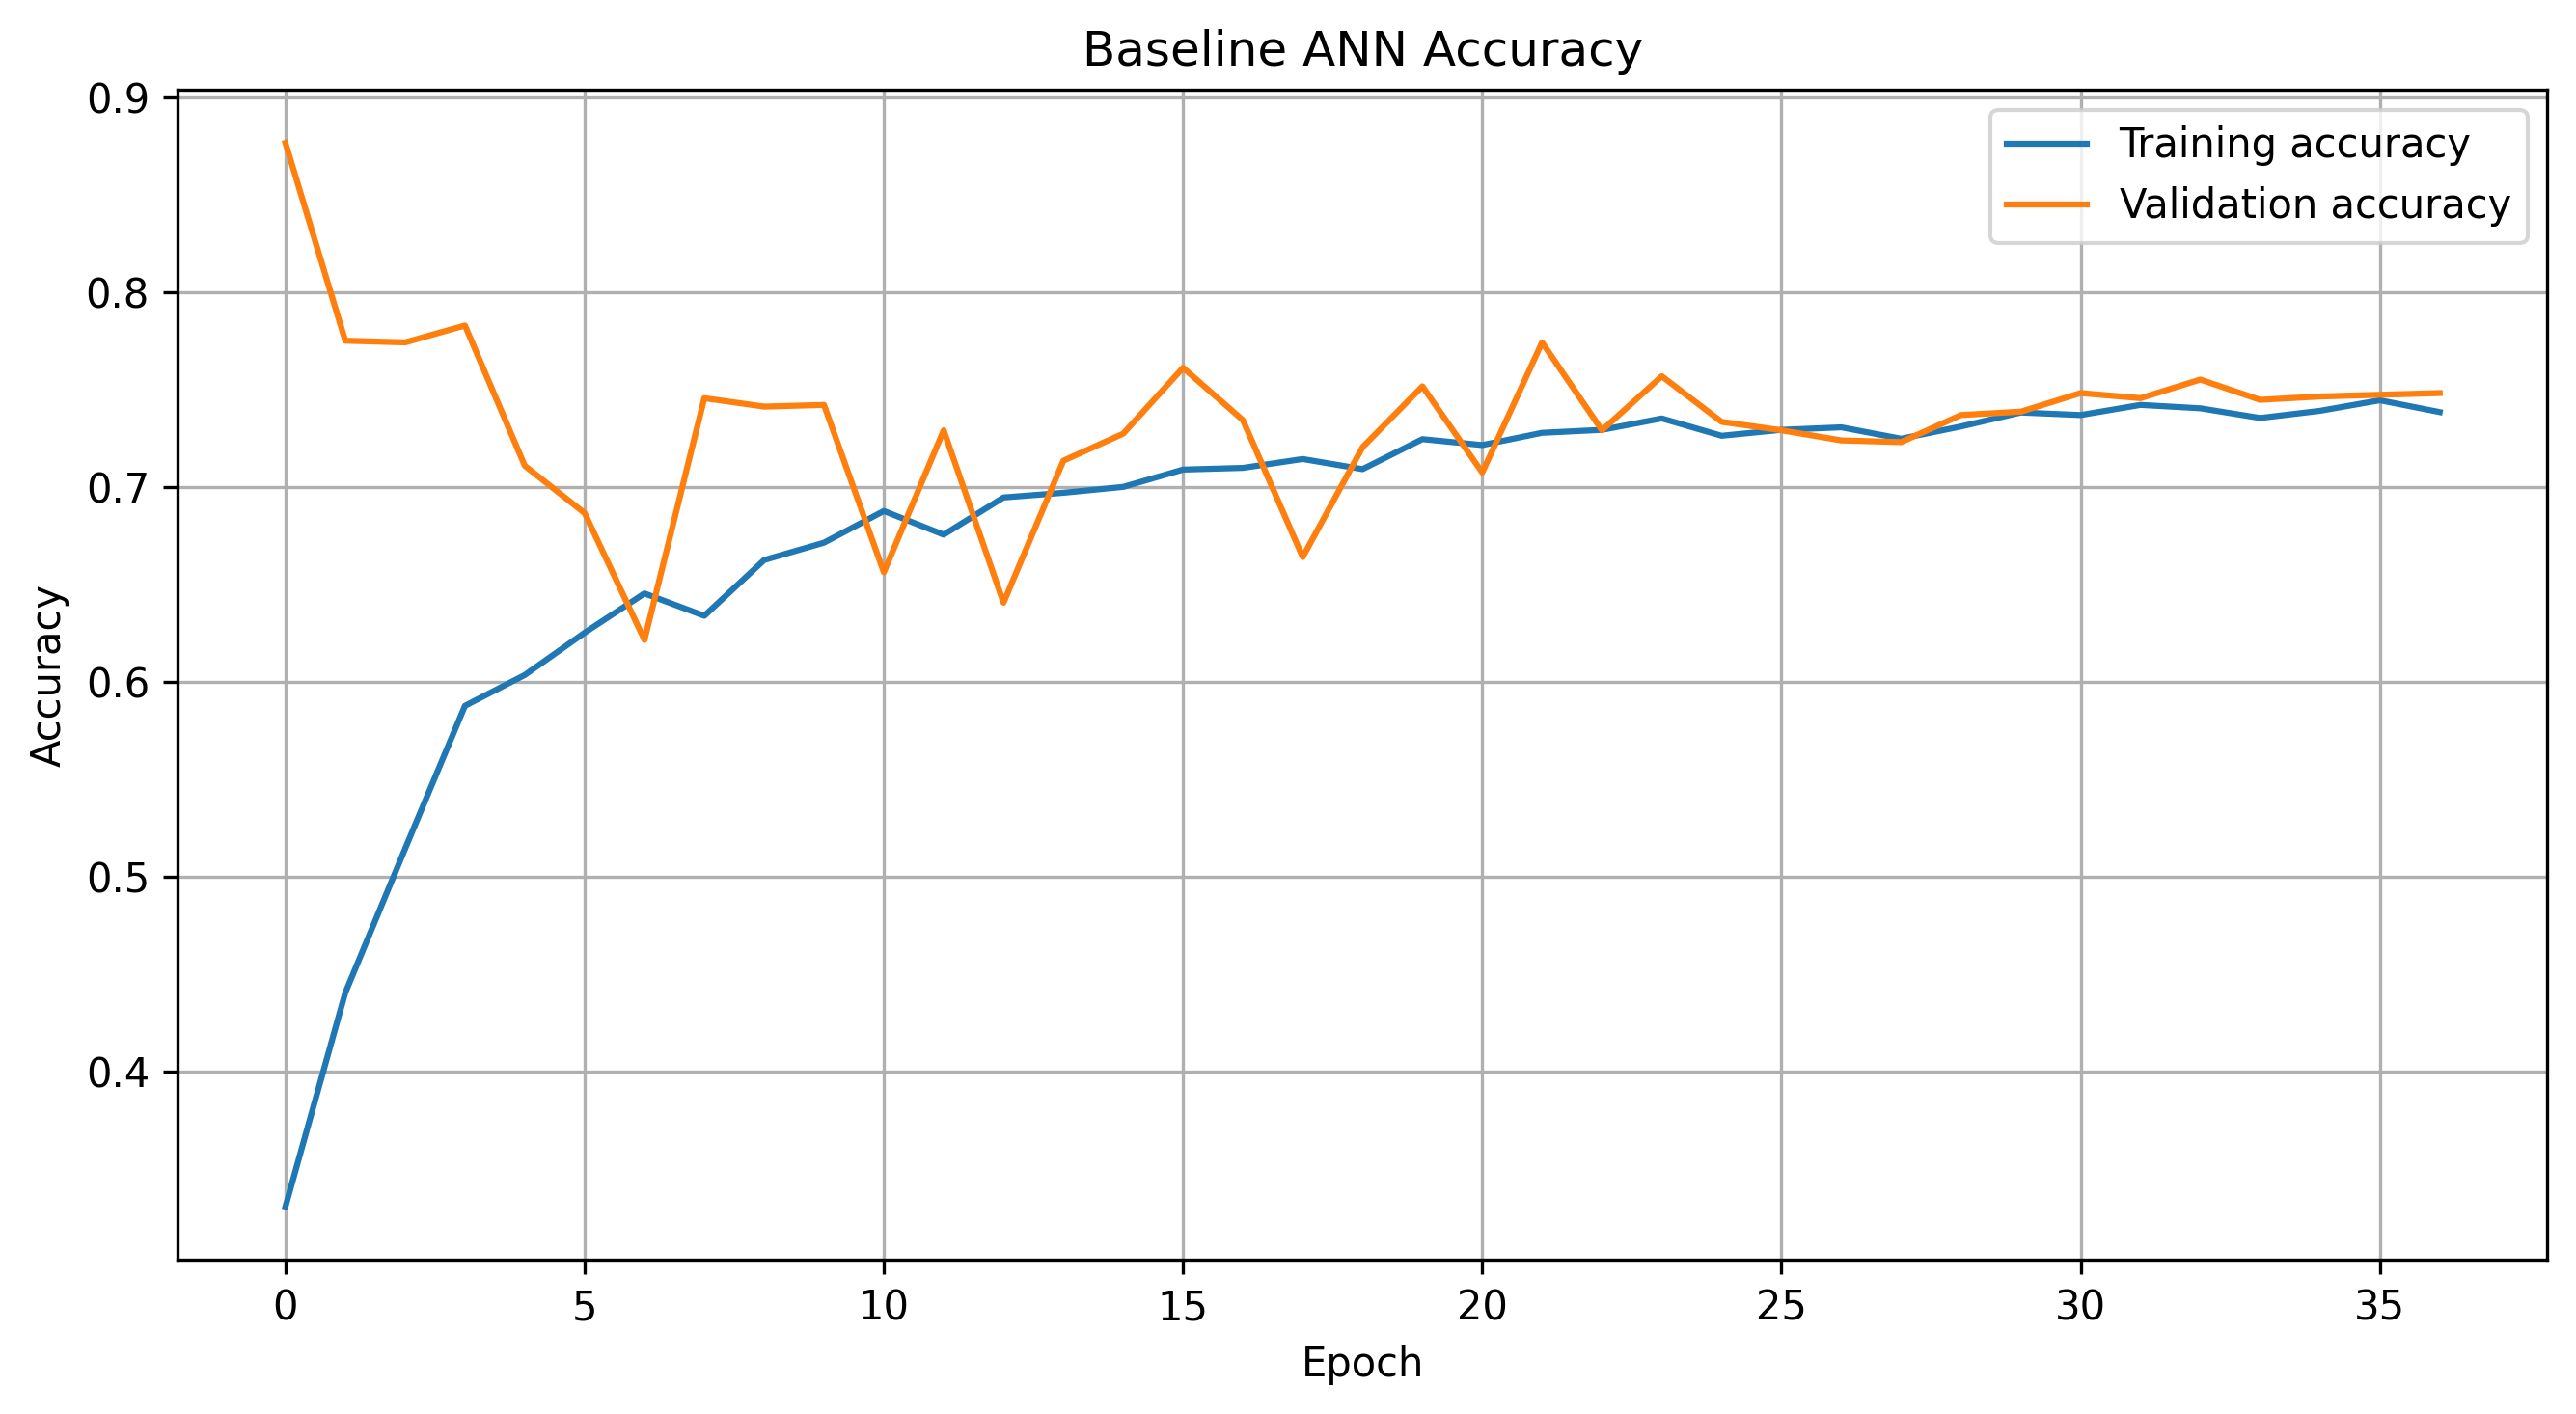

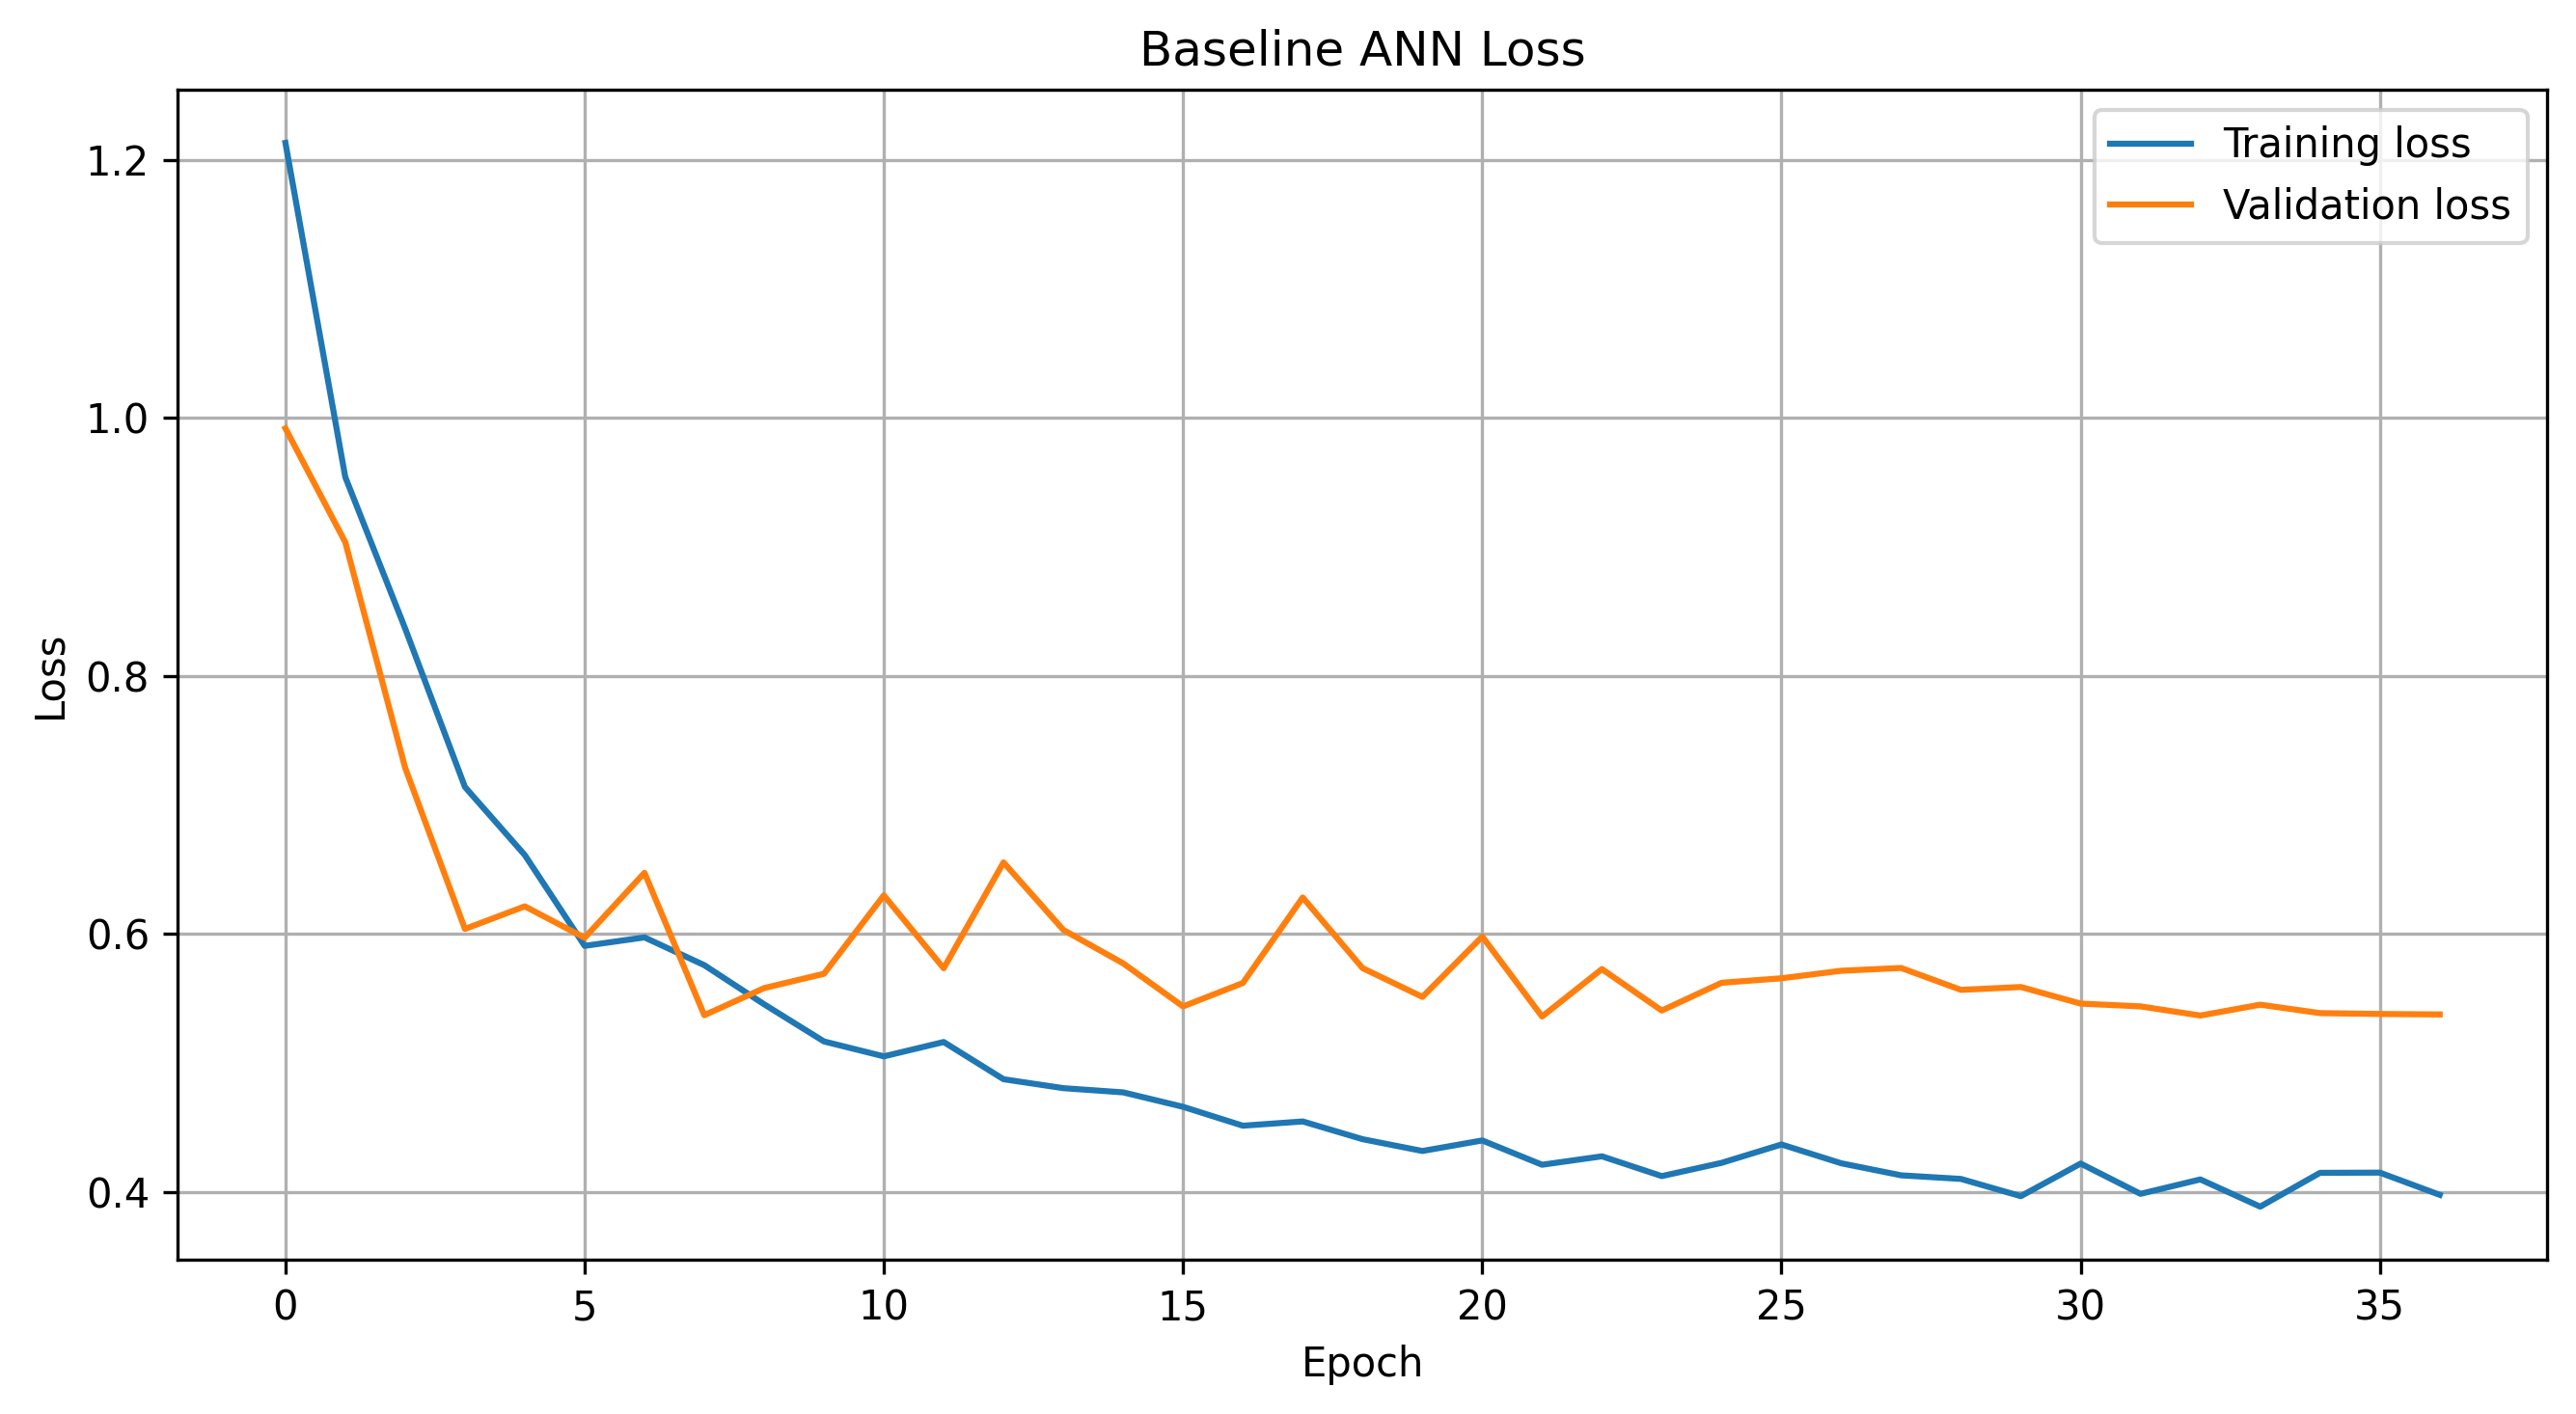

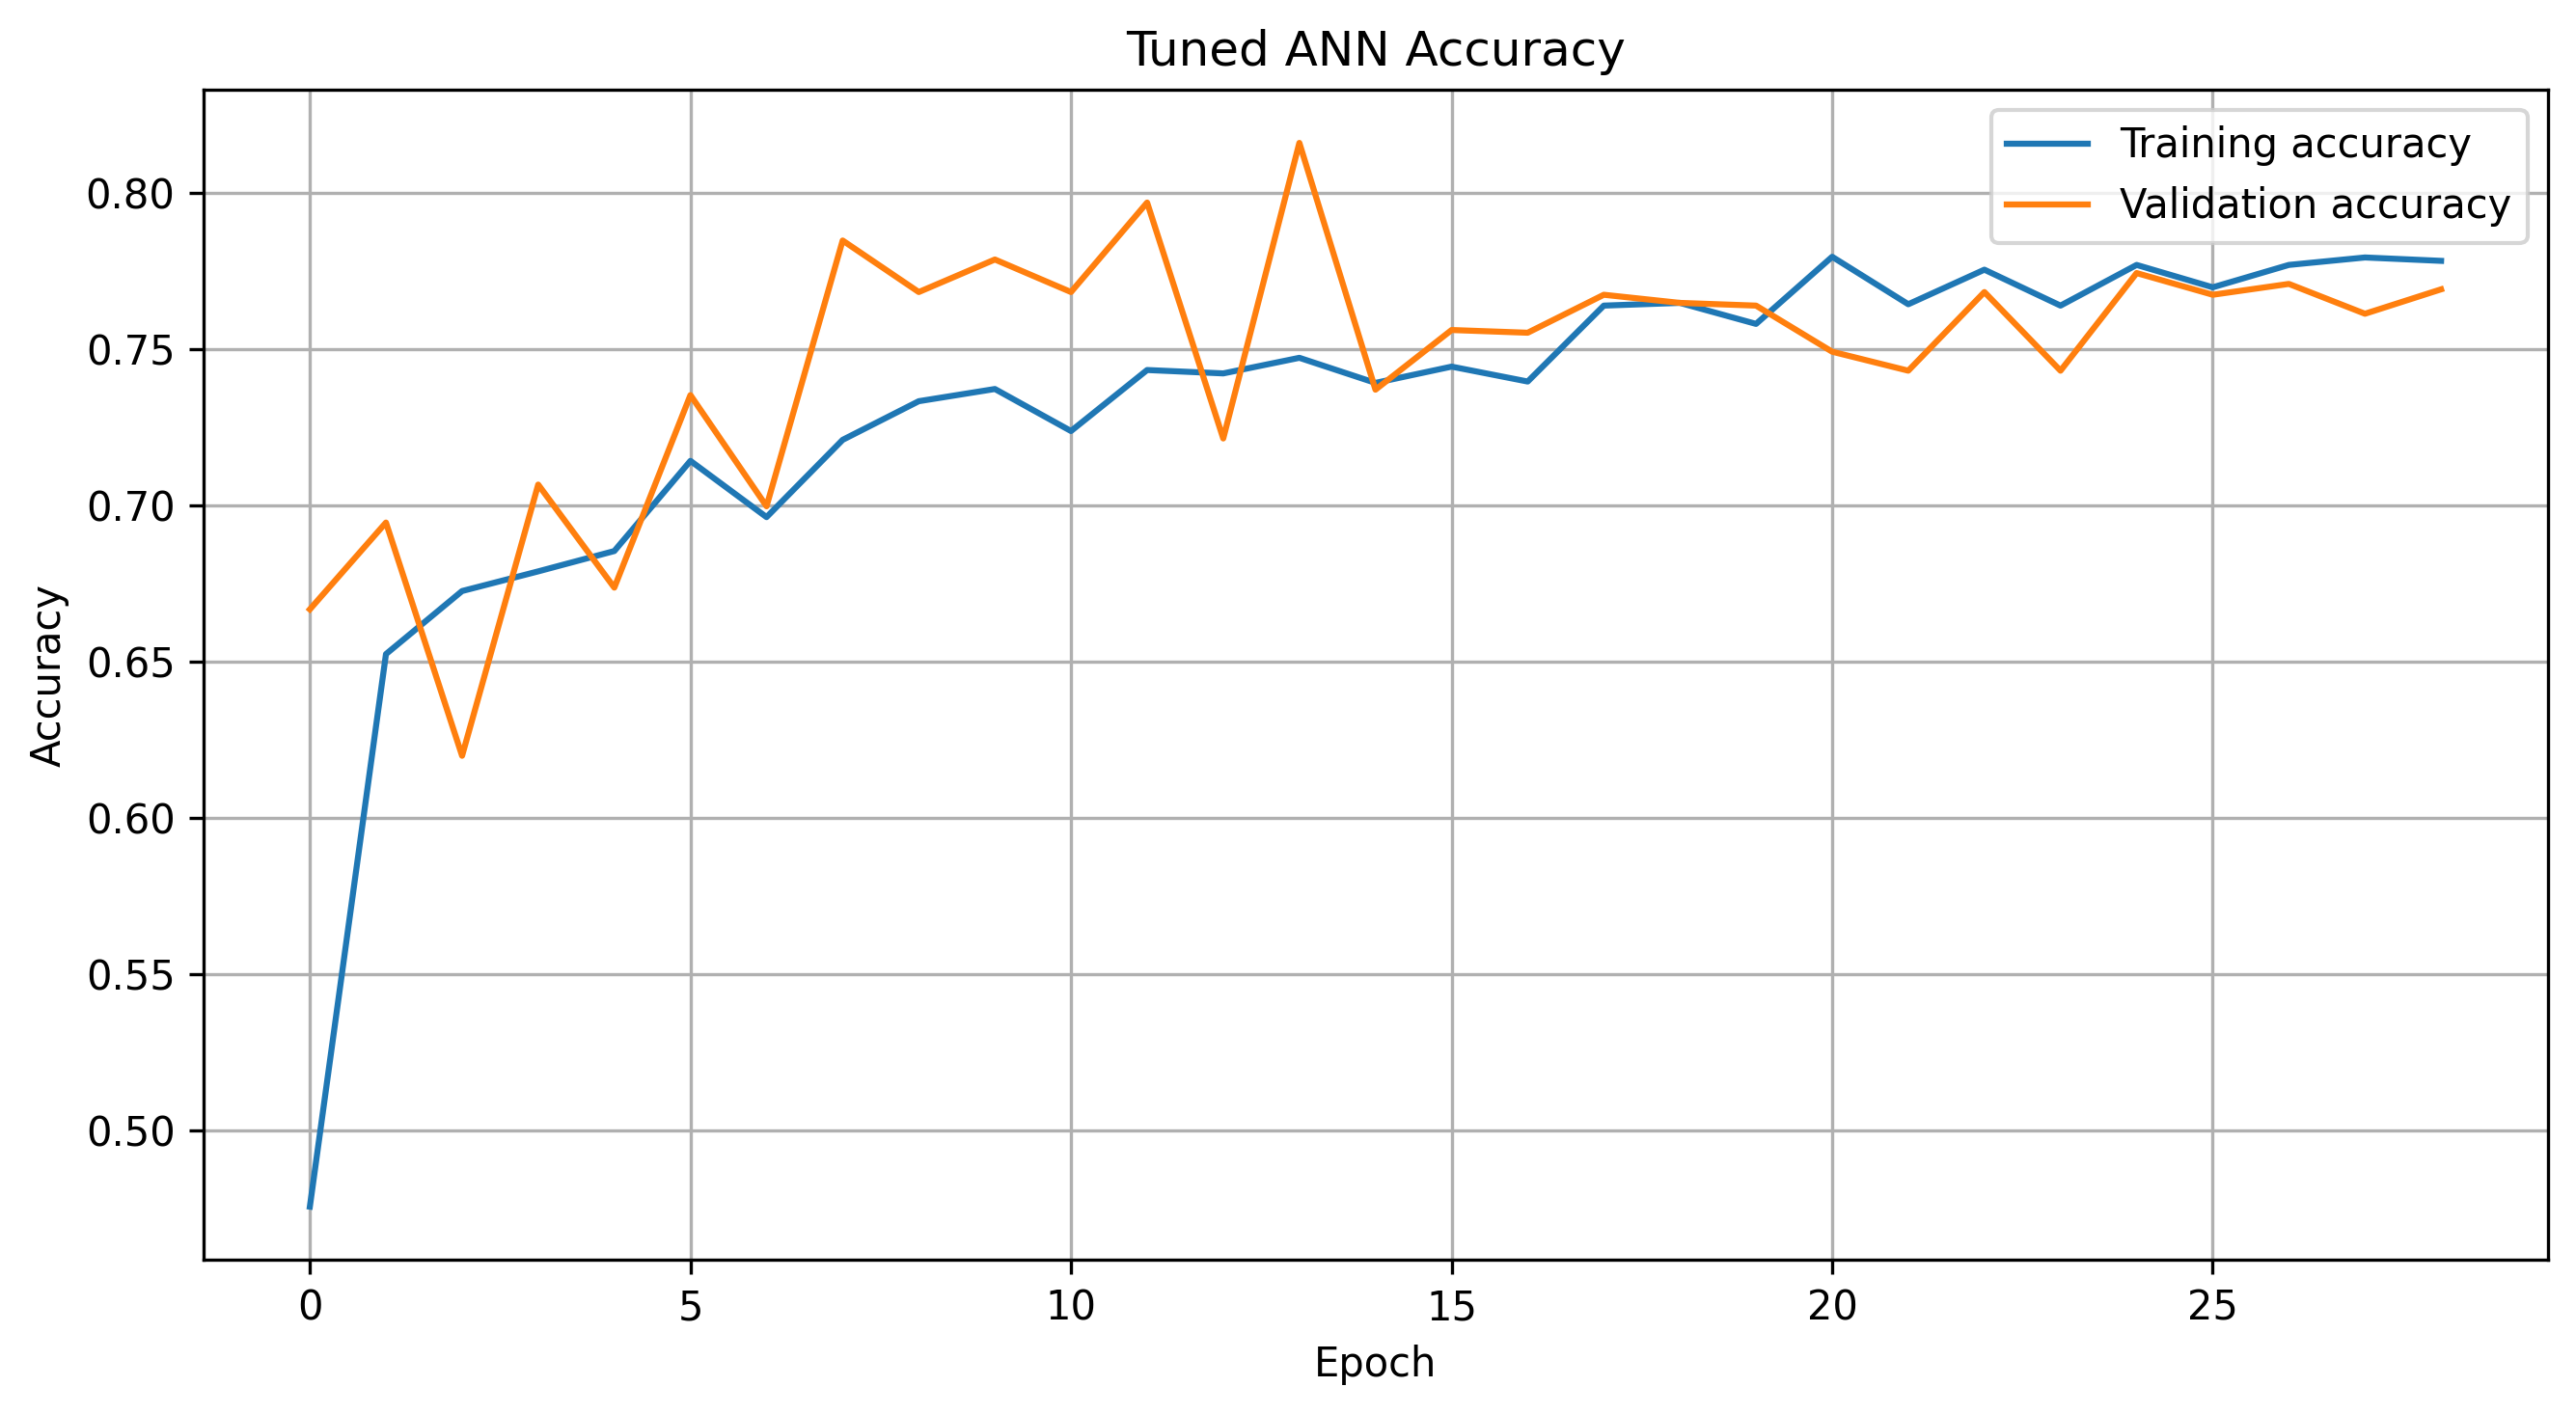

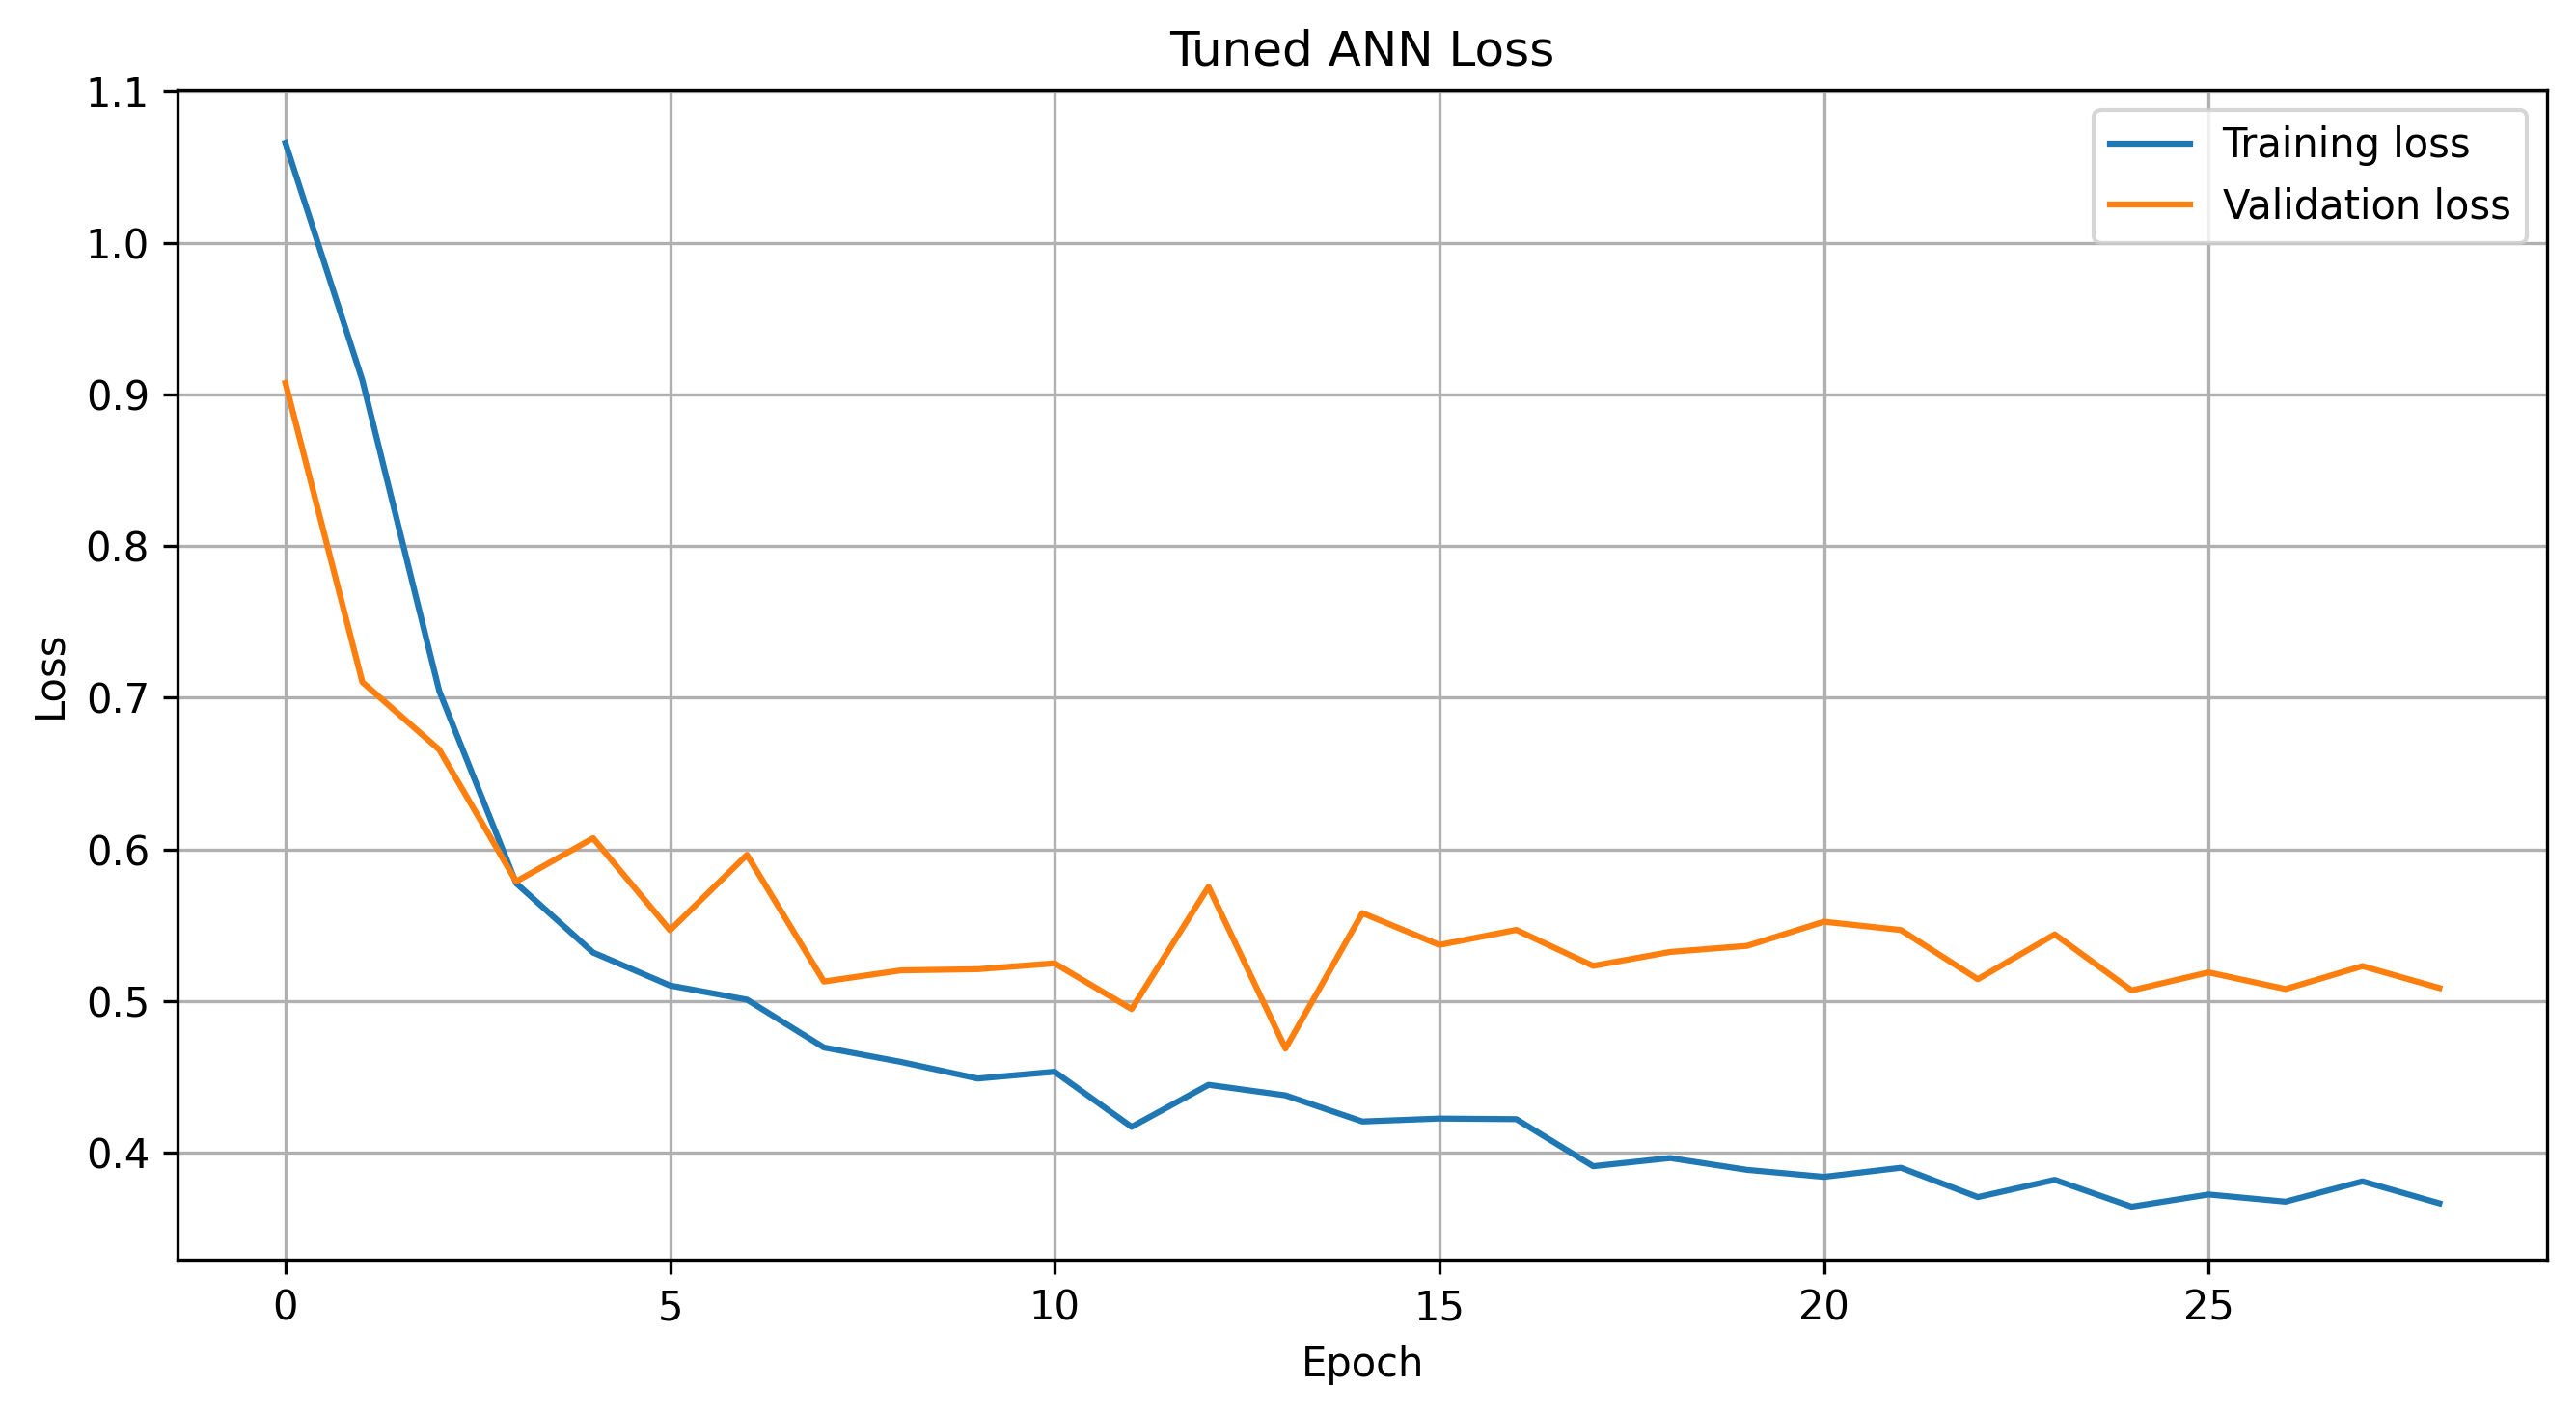

In [53]:
from IPython.display import Image, display

display(
    Image(
        filename="results/baseline_ann_accuracy.png"
    )
)

display(
    Image(
        filename="results/baseline_ann_loss.png"
    )
)

display(
    Image(
        filename="results/tuned_ann_accuracy.png"
    )
)

display(
    Image(
        filename="results/tuned_ann_loss.png"
    )
)

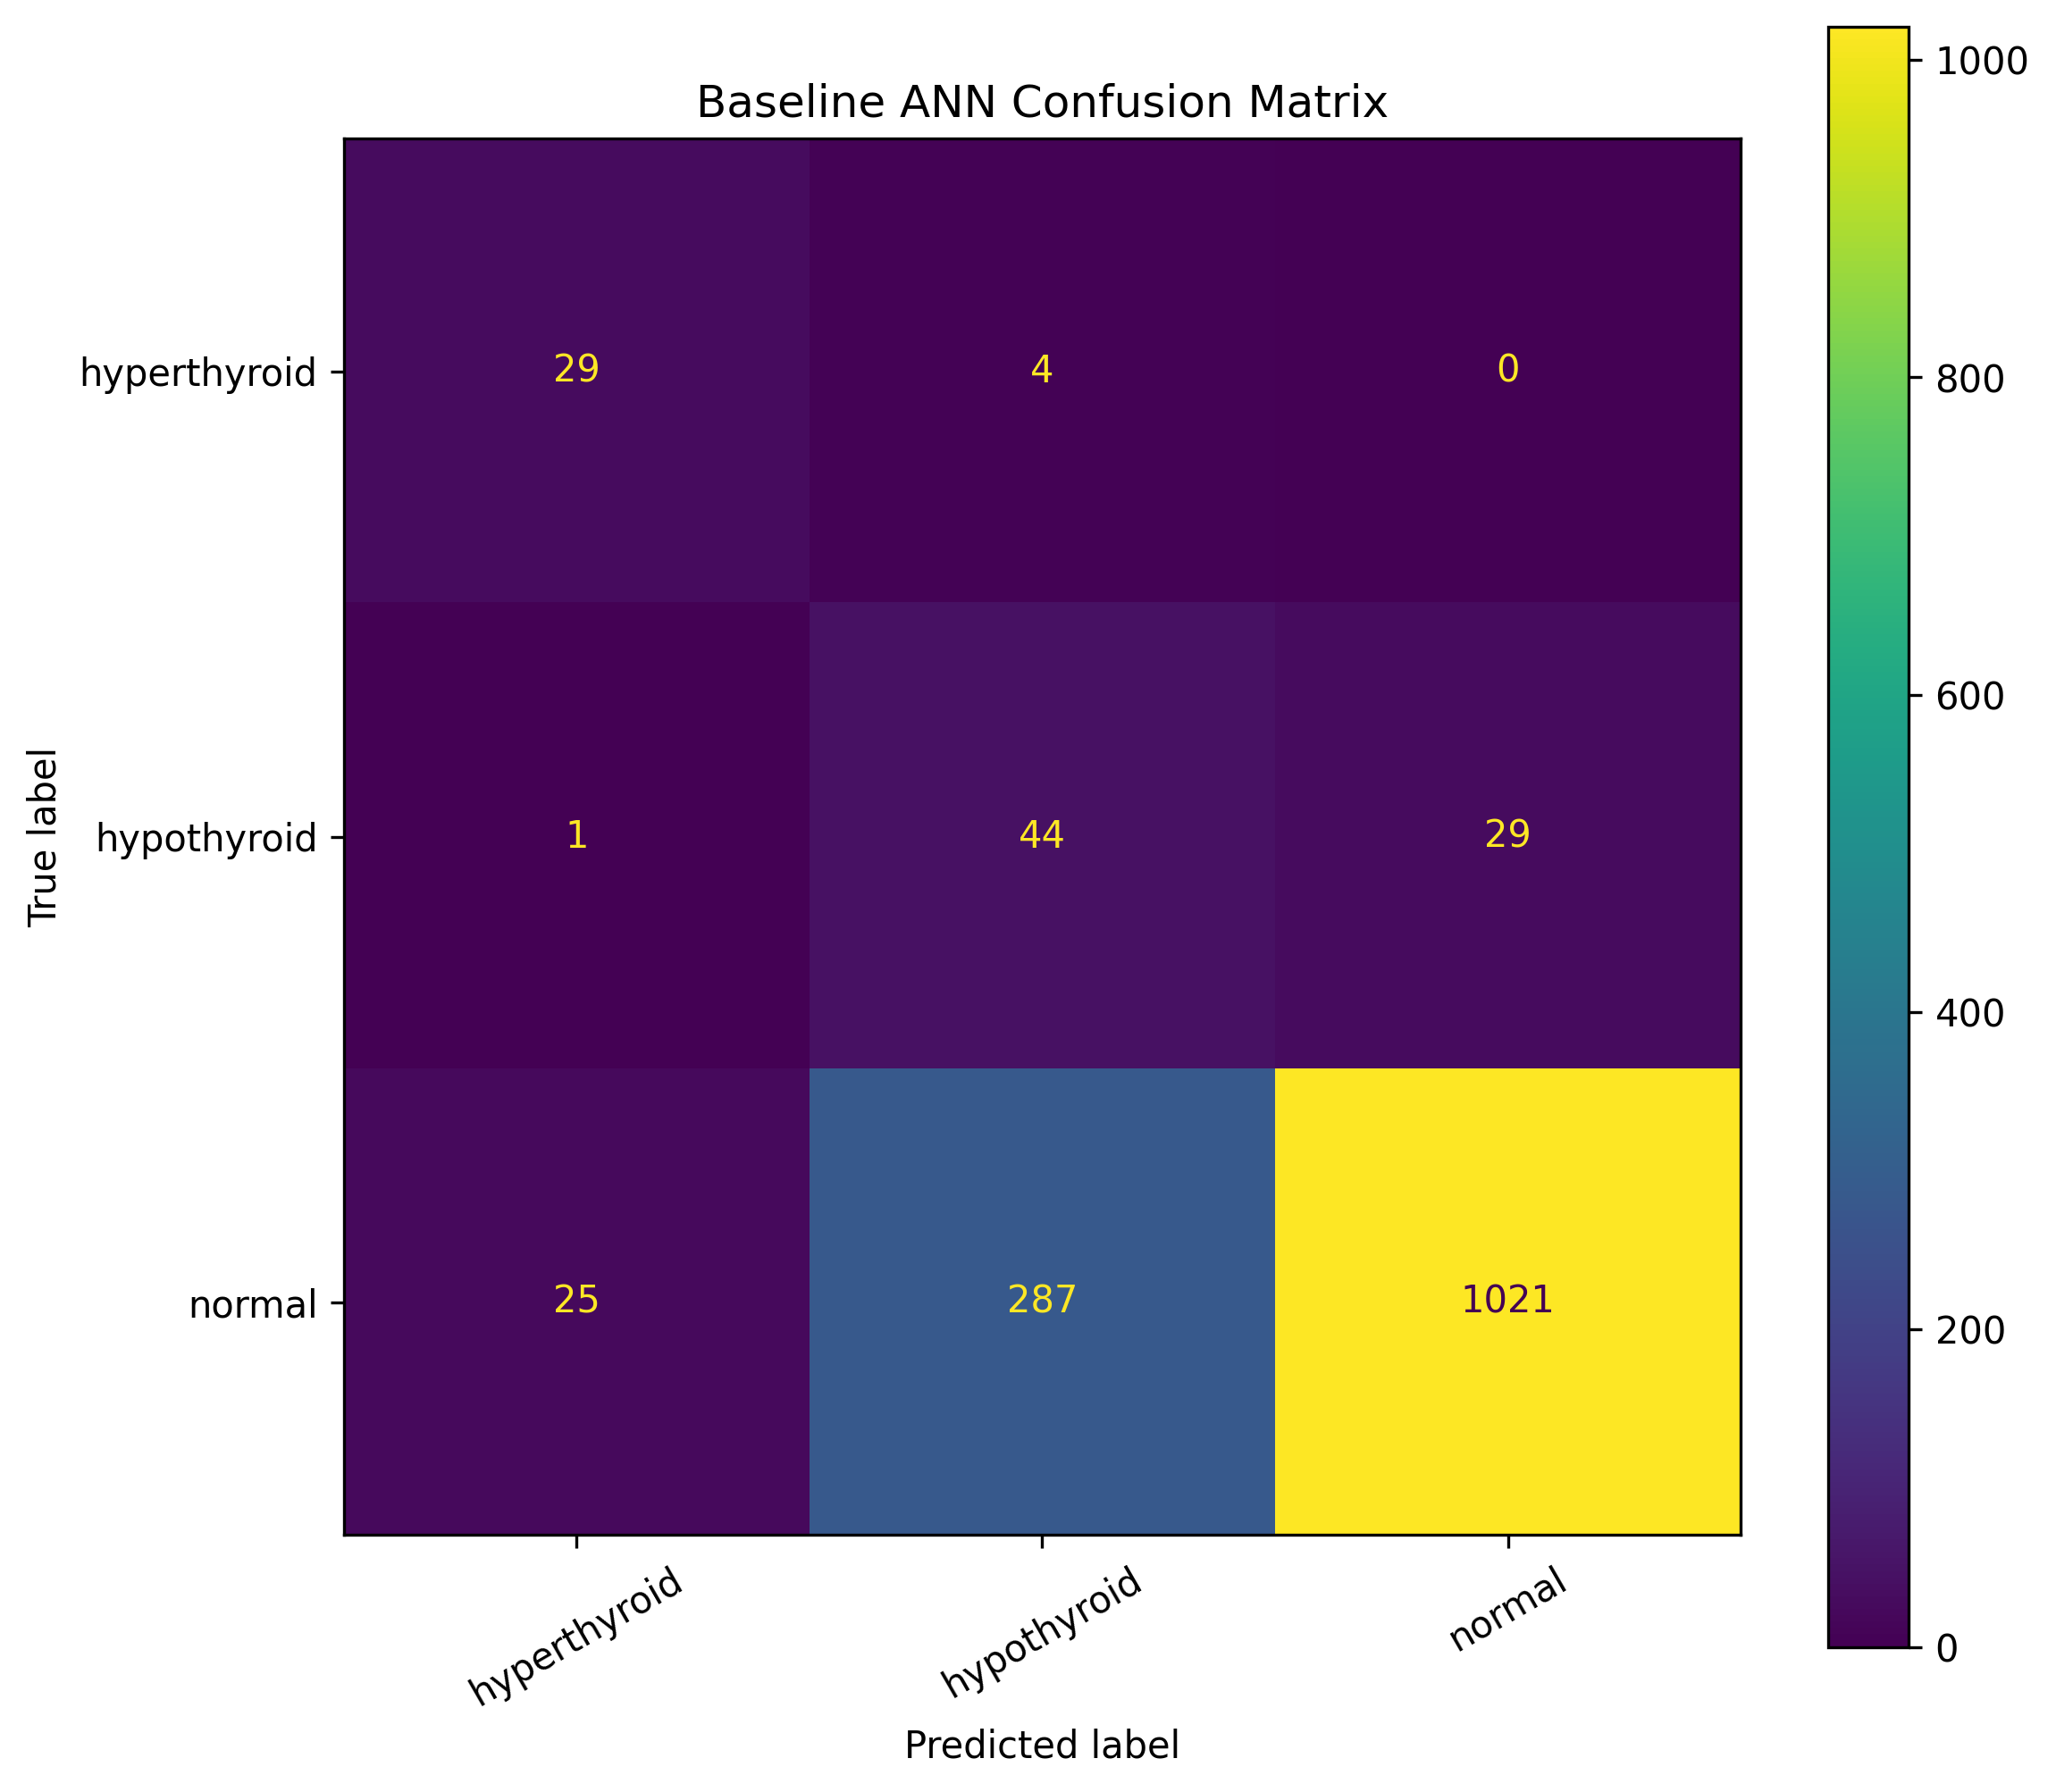

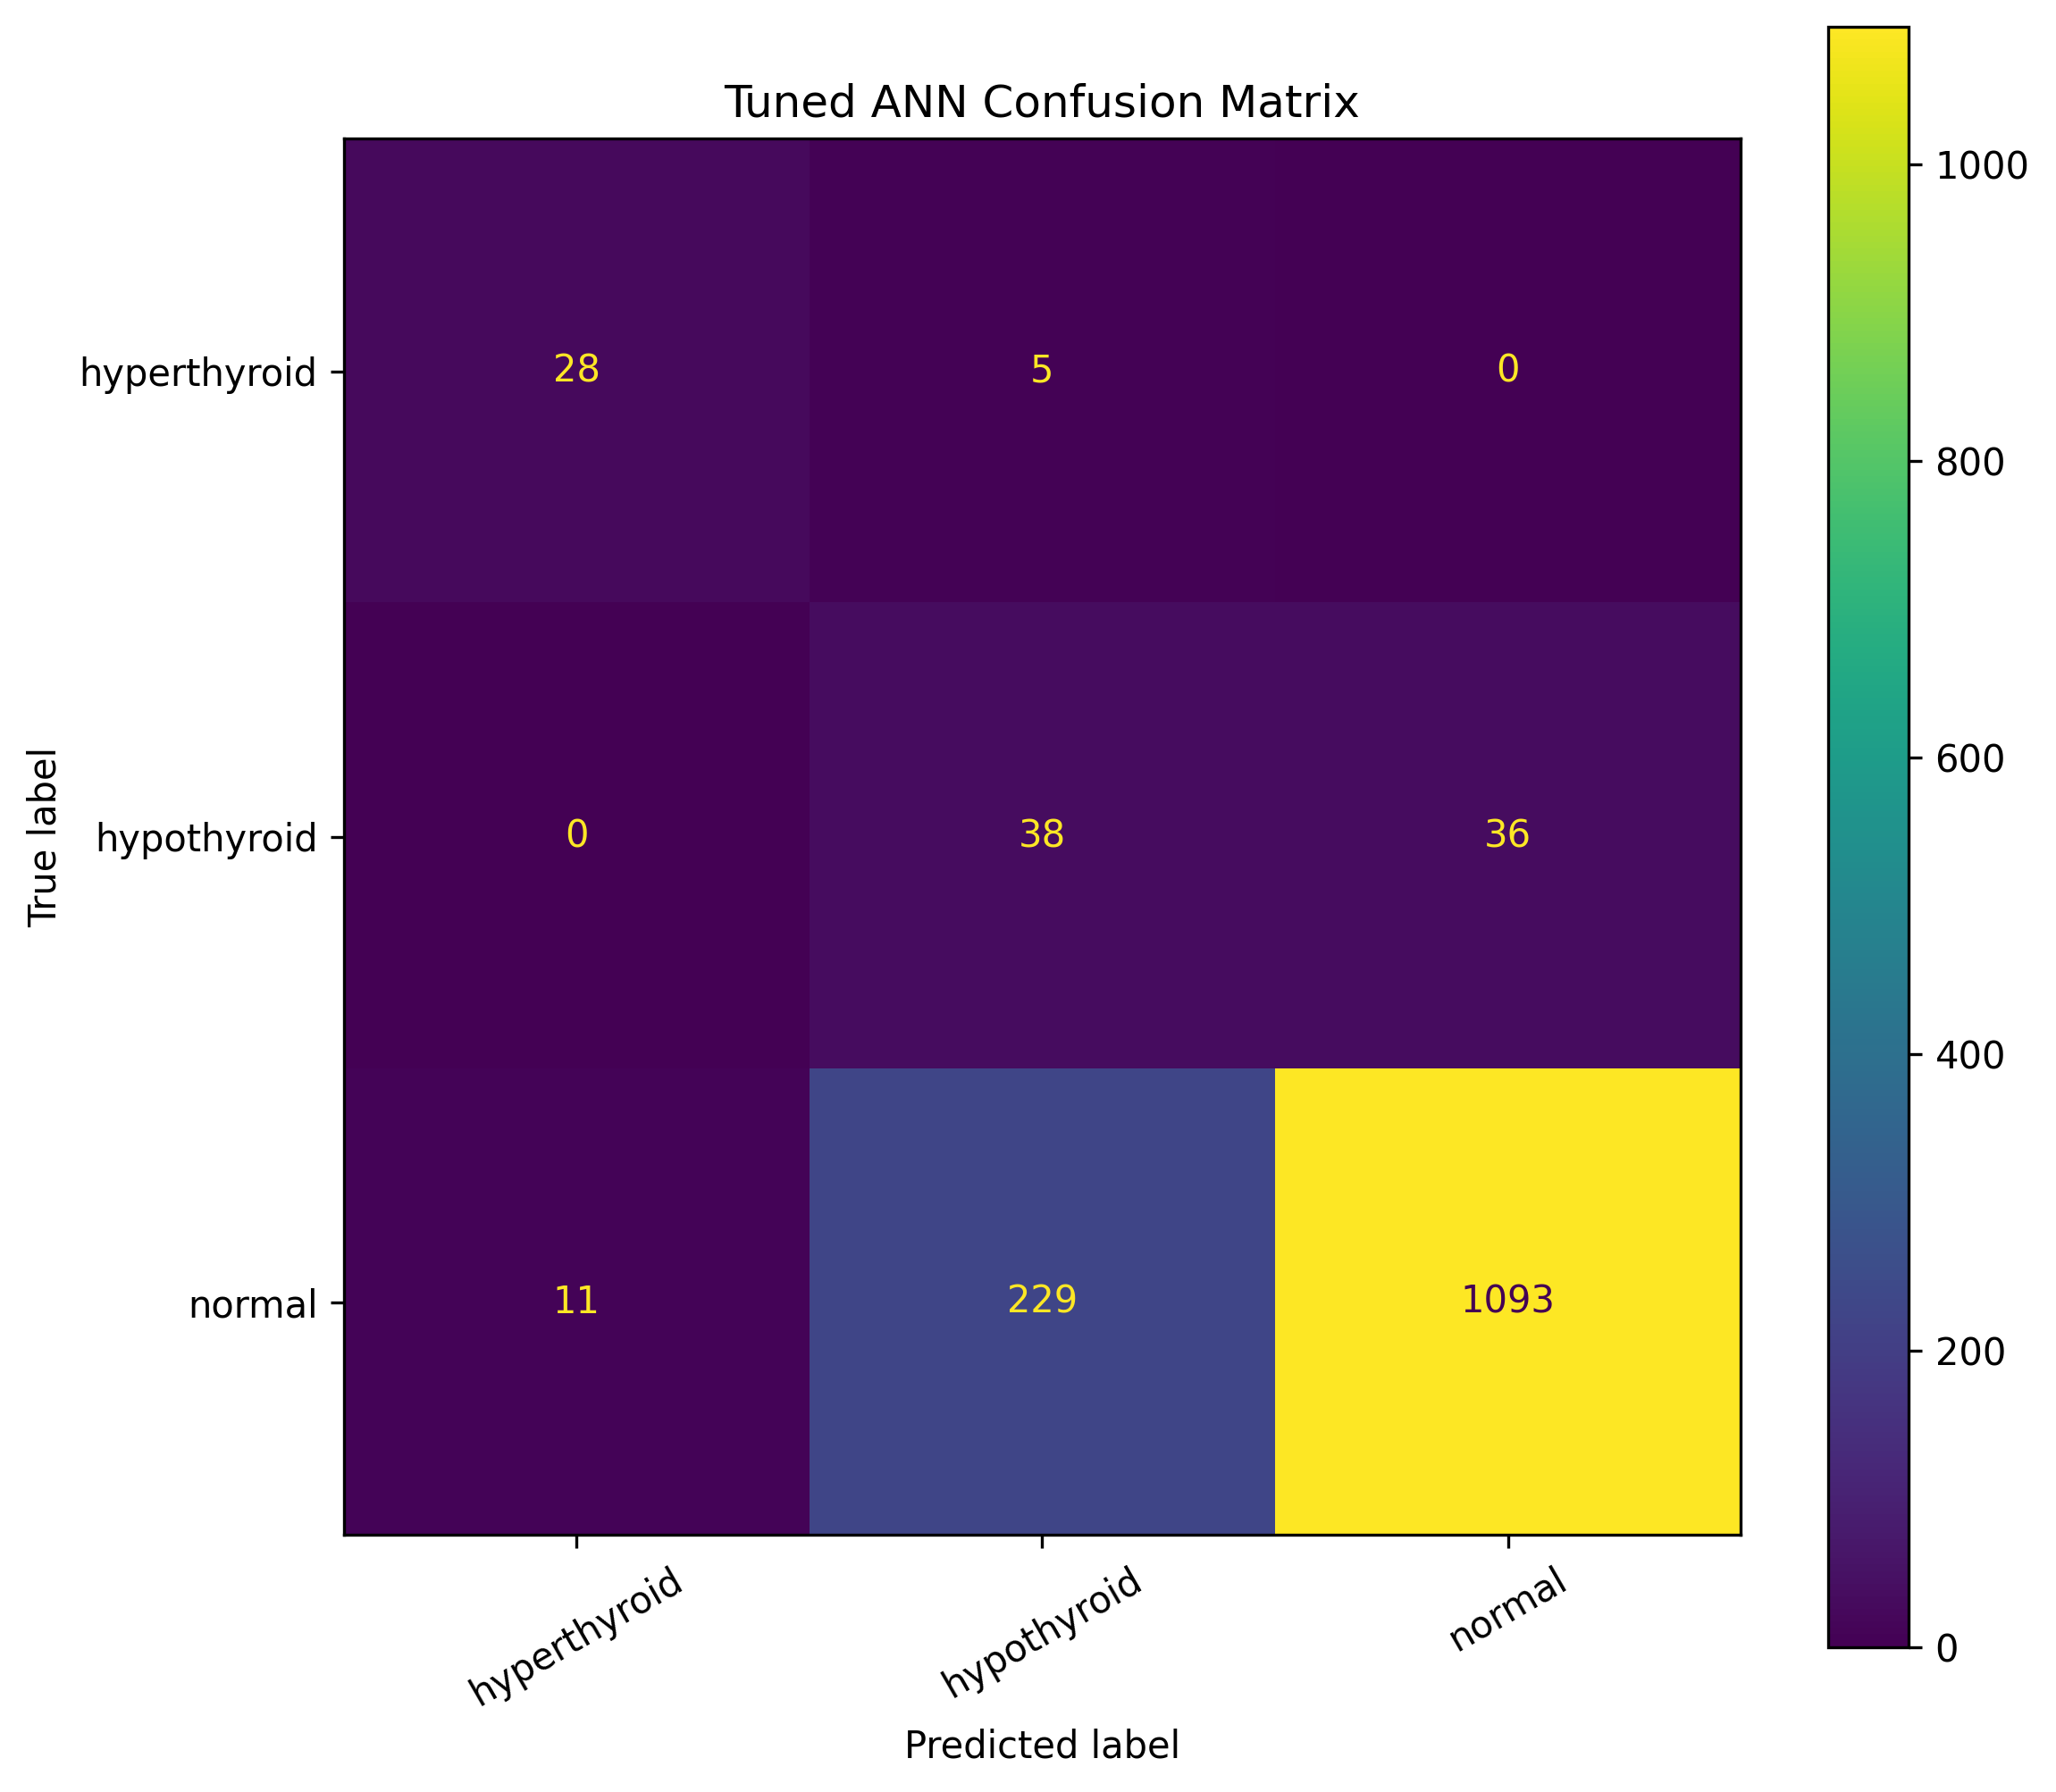

In [54]:
display(
    Image(
        filename="results/baseline_ann_confusion_matrix.png"
    )
)

display(
    Image(
        filename="results/tuned_ann_confusion_matrix.png"
    )
)

In [55]:
comparison = pd.read_csv(
    "results/ann_before_after_tuning.csv"
)

best_row = comparison.sort_values(
    by=[
        "Macro F1",
        "Balanced Accuracy"
    ],
    ascending=False
).iloc[0]

print("Recommended ANN:", best_row["Model"])
print(best_row)

Recommended ANN: Tuned ANN
Model                Tuned ANN
Accuracy              0.804861
Balanced Accuracy     0.727318
Macro Precision       0.608589
Macro Recall          0.727318
Macro F1              0.628442
Weighted F1           0.851032
Name: 1, dtype: object


In [56]:
import shutil

shutil.make_archive(
    "thyroid_ann_work",
    "zip",
    ".",
    "models"
)

shutil.make_archive(
    "thyroid_ann_results",
    "zip",
    ".",
    "results"
)

print("ZIP files created.")

ZIP files created.


In [57]:
from google.colab import files

files.download("thyroid_ann_work.zip")
files.download("thyroid_ann_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>